In [ ]:
# Setup — eseguire solo la prima volta
# import subprocess
# subprocess.run(["git", "clone", "https://github.com/waico/SKAB"])

# Esplorazione del dataset SKAB

Il dataset SKAB (Skoltech Anomaly Benchmark) è un benchmark industriale reale raccolto da un impianto idraulico presso il Skolkovo Institute of Science and Technology. Contiene serie temporali multivariate di 8 sensori fisici con label timestep-level delle anomalie, il che lo rende adatto a valutare metodi di anomaly detection con graduale transizione da normale ad anomalo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = "SKAB/data"

# Carichiamo i dati normali
df_normal = pd.read_csv(os.path.join(DATA_PATH, "anomaly-free/anomaly-free.csv"), sep=";")
print(df_normal.shape)
print(df_normal.head())

(9405, 9)
              datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0  2020-02-08 13:30:47           0.202394           0.275154  2.16975   
1  2020-02-08 13:30:48           0.203153           0.277857  2.07999   
2  2020-02-08 13:30:50           0.202054           0.275790  2.52577   
3  2020-02-08 13:30:51           0.203595           0.278101  2.49742   
4  2020-02-08 13:30:52           0.201889           0.276363  2.29194   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
0  0.382638      90.6454       26.8508  238.852              122.664  
1 -0.273216      90.7978       26.8639  227.943              122.338  
2  0.382638      90.7730       26.8603  223.486              121.338  
3  0.054711      90.8424       26.8616  244.904              121.664  
4  0.710565      90.6664       26.8603  239.196              122.000  


## File anomali

I file con anomalie hanno due colonne aggiuntive: `anomaly` (0/1) indica se il timestep è anomalo, `changepoint` (0/1) indica il punto di inizio del cambiamento. Questo ci permette di sapere esattamente quando inizia ogni anomalia e di calcolare il ritardo di rilevamento in modo preciso.

In [2]:
# Carichiamo un file con anomalia
df_anom = pd.read_csv(os.path.join(DATA_PATH, "valve1/1.csv"), sep=";")
print(df_anom.shape)
print(df_anom.columns.tolist())
print(df_anom["anomaly"].value_counts())

(1145, 11)
['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
anomaly
0.0    743
1.0    402
Name: count, dtype: int64


## Visualizzazione delle feature durante un'anomalia

Le 8 feature di `valve1/1.csv` mostrate con i timestep anomali evidenziati in rosso. Feature come Temperature e Volume Flow RateRMS mostrano cambiamenti graduali nella zona anomala, fisicamente interpretabili come effetto della chiusura progressiva della valvola.

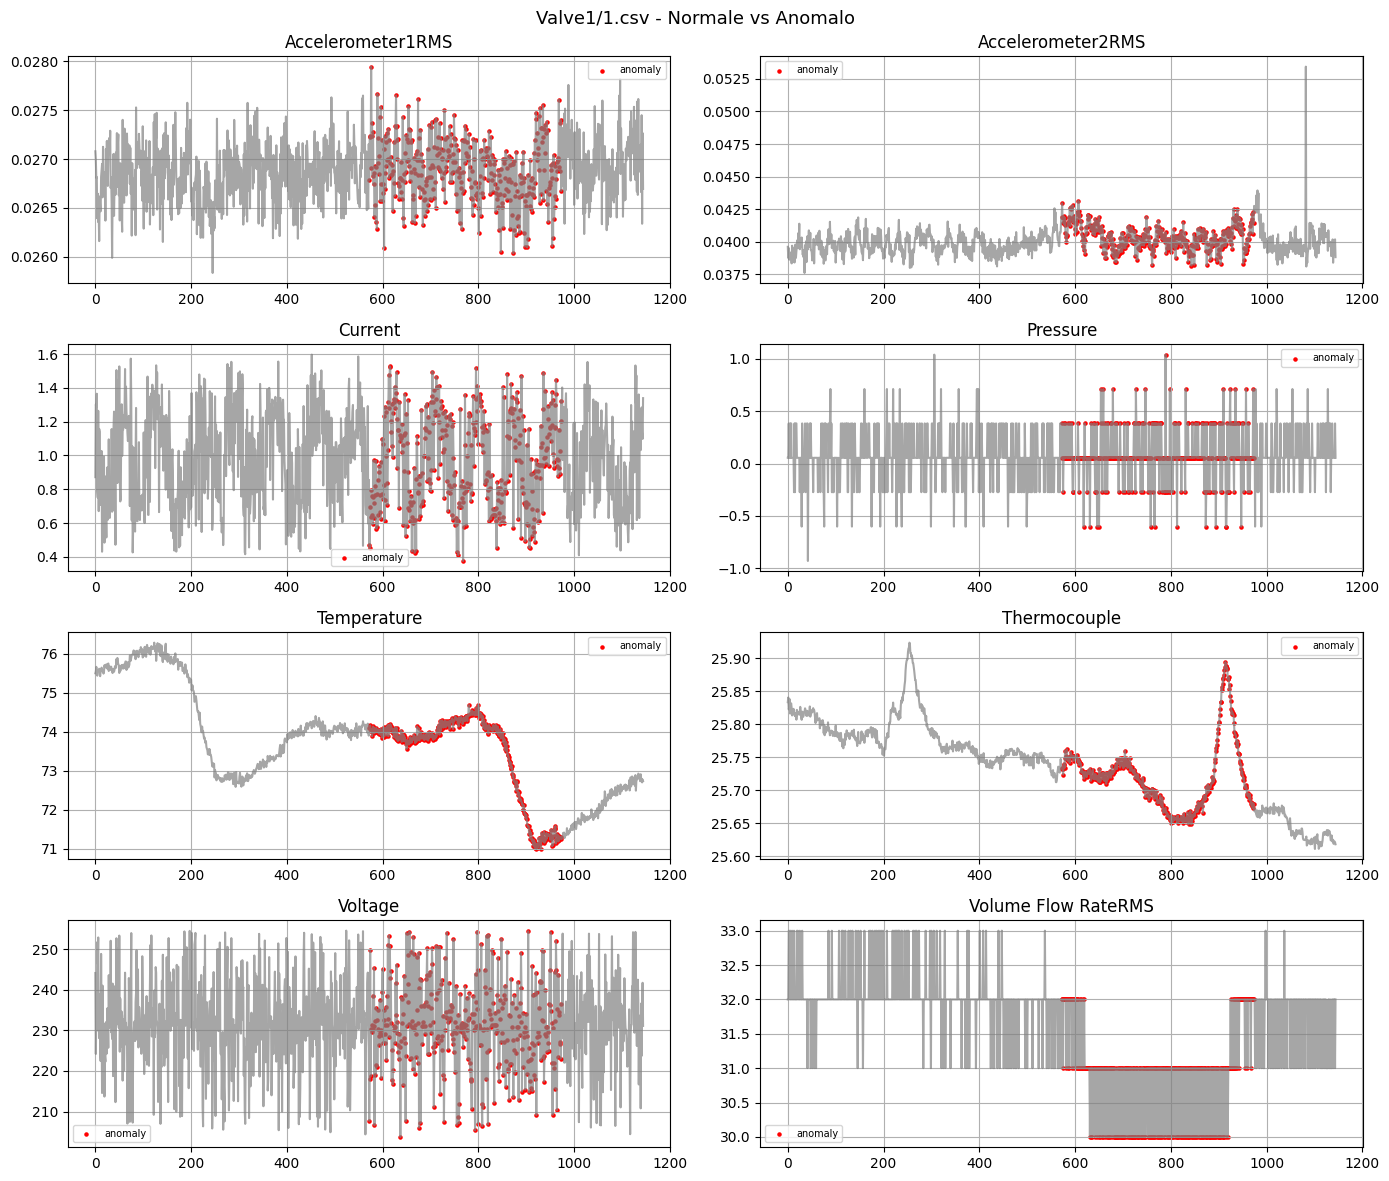

In [3]:
features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].plot(df_anom[feat], color="gray", alpha=0.7)
    # Coloriamo i punti anomali in rosso
    anomaly_idx = df_anom[df_anom["anomaly"] == 1].index
    axes[i].scatter(anomaly_idx, df_anom.loc[anomaly_idx, feat], 
                   color="red", s=5, label="anomaly")
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)
    axes[i].grid(True)

plt.suptitle("Valve1/1.csv - Normale vs Anomalo", fontsize=13)
plt.tight_layout()
plt.show()